In [47]:
import sys
sys.path.append('/root/capsule/aind-beh-ephys-analysis/code/beh_ephys_analysis/utils')
import nest_asyncio
import stan
import numpy as np
import pandas as pd
import os
from os import path
import glob
from RLmodels import QLearningModel
# from RLmodels import qLearningModel_5params_simNoPlot
from RLmodels import RestlessBanditDecoupled
from RLmodels import QLearningModelSim, myPairPlot, getSessionFitParams
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
from scipy.stats import spearmanr
from scipy.stats import pearsonr
import re
from scipy.stats import norm
from scipy.stats import halfcauchy
from scipy.stats import cauchy
from sklearn.linear_model import LinearRegression
import pickle
import json
nest_asyncio.apply()
from aind_dynamic_foraging_basic_analysis.licks.lick_analysis import plot_lick_analysis, load_data, load_nwb, cal_metrics, plot_met
from beh_functions import parseSessionID, session_dirs, plot_session_glm, plot_session_in_time_all, bonsai_to_nwb, transfer_nwb
from aind_dynamic_foraging_basic_analysis import plot_foraging_session
from aind_dynamic_foraging_data_utils.nwb_utils import load_nwb_from_filename
import statsmodels.api as sm
import json
%matplotlib inline

In [2]:
import nest_asyncio
import stan
import numpy as np
import pandas as pd
import os
import sys
import ast
import pickle
from os import path


In [5]:

# --- external utils bootstrap ---
_utils_candidates = [
    '/src/external/aind-beh-ephys-analysis/code/beh_ephys_analysis/utils',
]
_utils_path = next((p for p in _utils_candidates if p and os.path.isdir(p)), None)
if _utils_path is None:
    raise RuntimeError(
        'aind-beh-ephys-analysis utils not found. Checked:\n'
        + '\n'.join([p for p in _utils_candidates if p])
        + '\nRun postInstall or set AIND_BEH_EPHYS_UTILS to the correct path.'
    )
sys.path.insert(0, _utils_path)
print(f'[bootstrap] using beh_ephys utils from: {_utils_path}')
try:
    import beh_functions  # smoke-test
except ImportError as e:
    raise ImportError(f'beh_functions not importable from {_utils_path}: {e}')
# --- end bootstrap ---

from RLmodels import getSessionFitParams

import arviz as az
from aind_dynamic_foraging_data_utils.nwb_utils import load_nwb_from_filename
from beh_functions import session_dirs, makeSessionDF

nest_asyncio.apply()

[bootstrap] using beh_ephys utils from: /src/external/aind-beh-ephys-analysis/code/beh_ephys_analysis/utils


In [48]:
# pip install PyPDF2
# pip install git+https://github.com/AllenNeuralDynamics/aind-dynamic-foraging-basic-analysis@plot_session_in_time_sue 

In [49]:
# pip install aind_dynamic_foraging_data_utils

In [50]:
# # load sessions
# # get list of available sessions
# file_pattern = "*.nwb"
# nwb_folder = "/root/capsule/data/foraging_nwb_bonsai"
# file_list = glob.glob(os.path.join(nwb_folder + "/" + file_pattern))
# file_names = [os.path.basename(file) for file in file_list]
# # file_name = file_names[20]
    
# results = [parseSessionID(file_name) for file_name in file_names]
# aniIDs, dates = zip(*results)

# sessionInfo = pd.DataFrame({'sessionID': file_names,
#                             'aniID': aniIDs,
#                             'date': dates})

In [51]:
# reference_date = datetime(2024, 5, 15)
# animalID = '717121'
# targetInds = np.where((sessionInfo['date'] >= reference_date) & (sessionInfo['aniID'] == animalID))[0]

In [56]:
ani_id = '699462'
save_csv = True
session_list = [data_asset[:-9] for data_asset in os.listdir('/root/capsule/data') if data_asset.endswith('_raw_data') and ani_id in data_asset]
# session_df = pd.read_csv('/root/capsule/aind-beh-ephys-analysis/code/data_management/hopkins_session_assets.csv')
# session_list = [session_id for session_id in session_df['session_id'] if ani_id in session_id]

behavior_699462_2024-01-03_12-05-59
Plotting session.


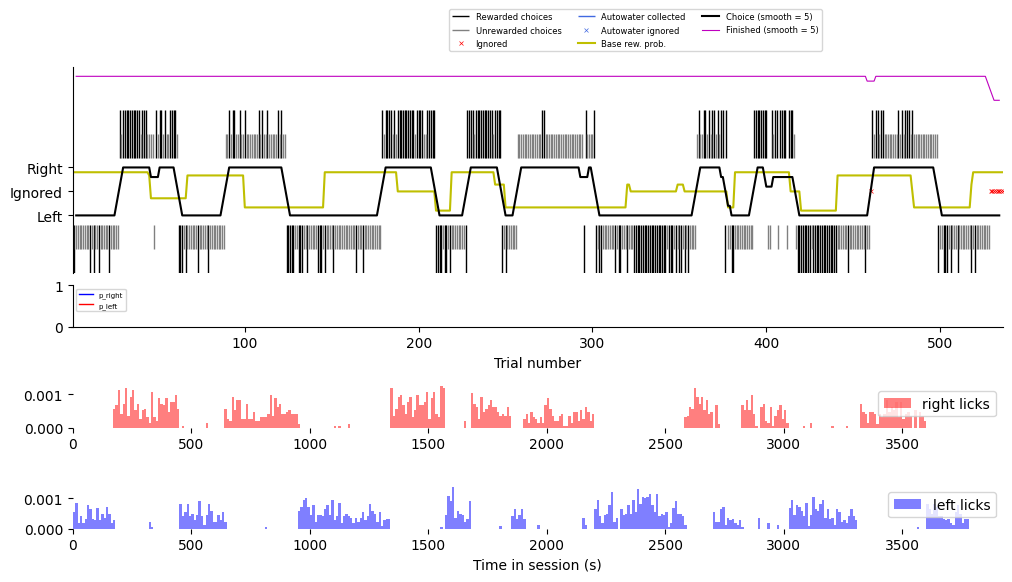

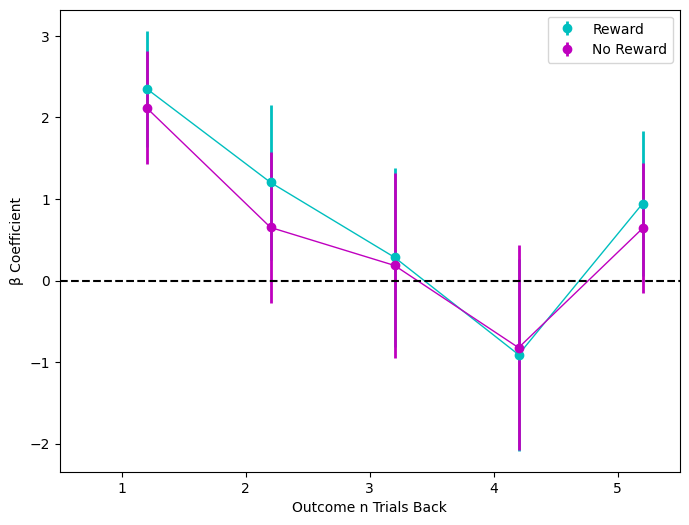

behavior_699462_2024-01-04_11-39-29
Plotting session.


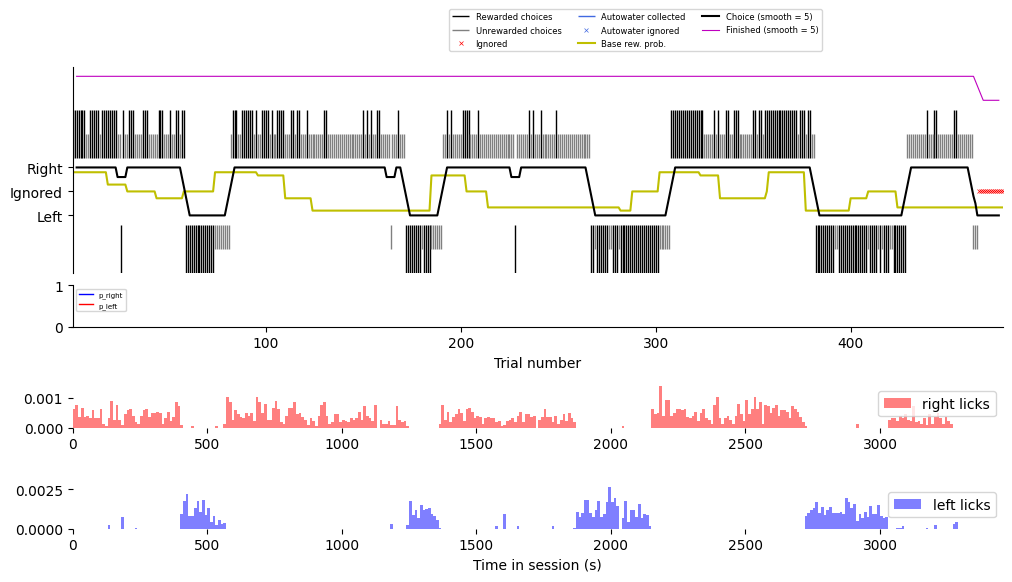

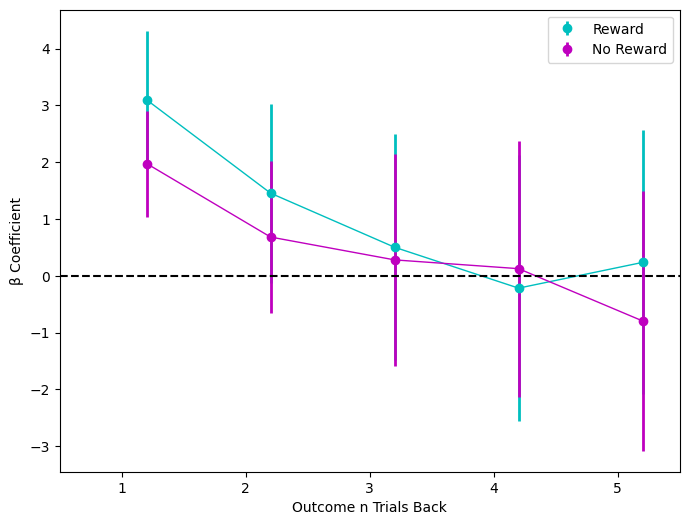

behavior_699462_2024-01-06_13-39-52
Plotting session.


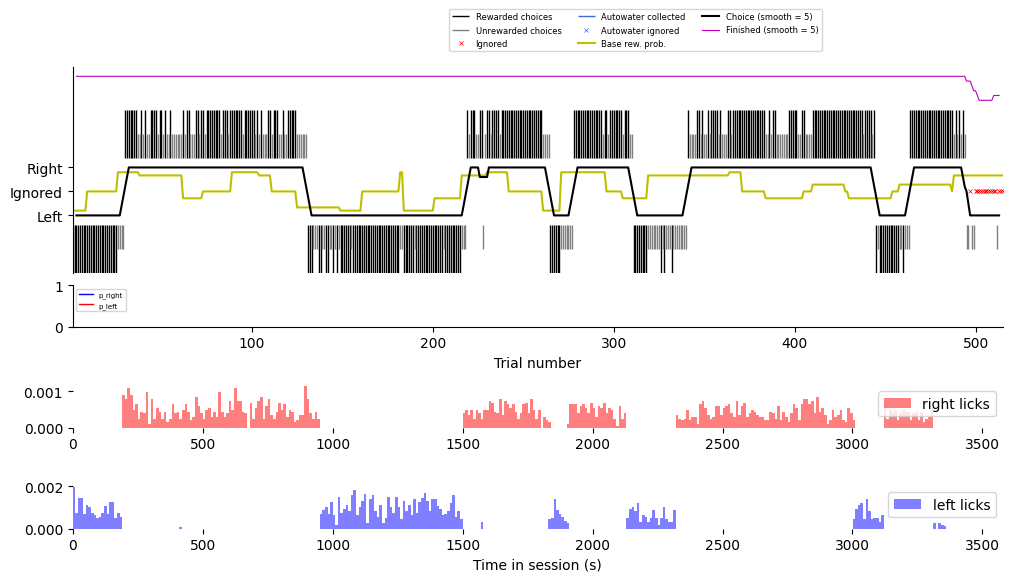

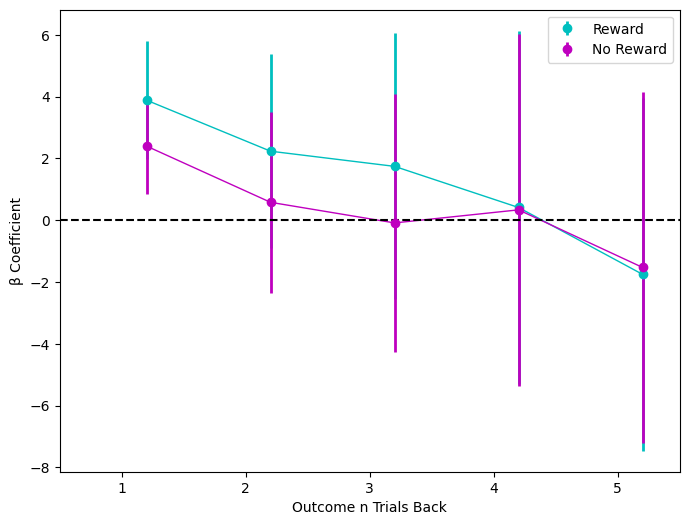

behavior_699462_2024-01-07_13-20-27
Plotting session.


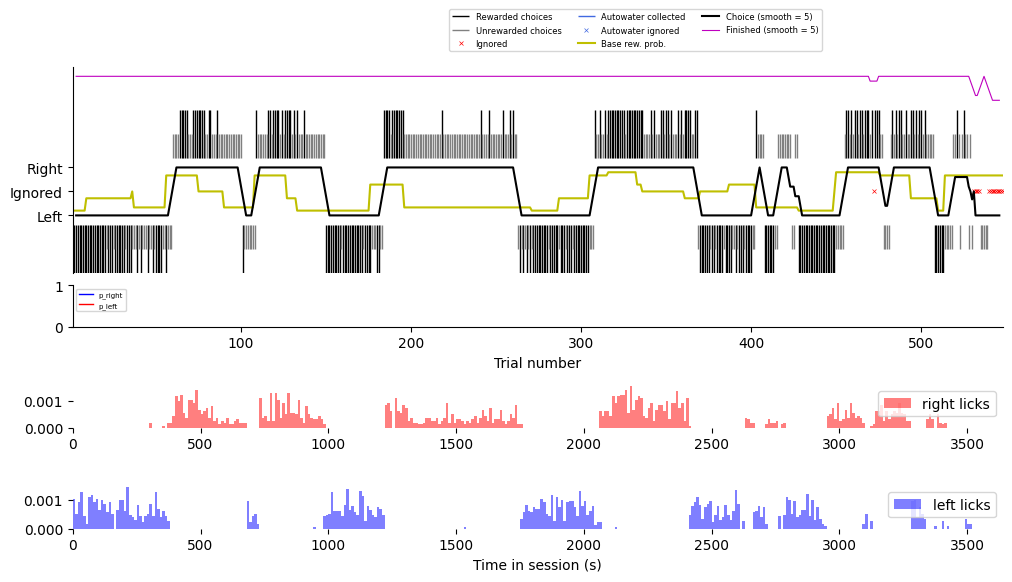

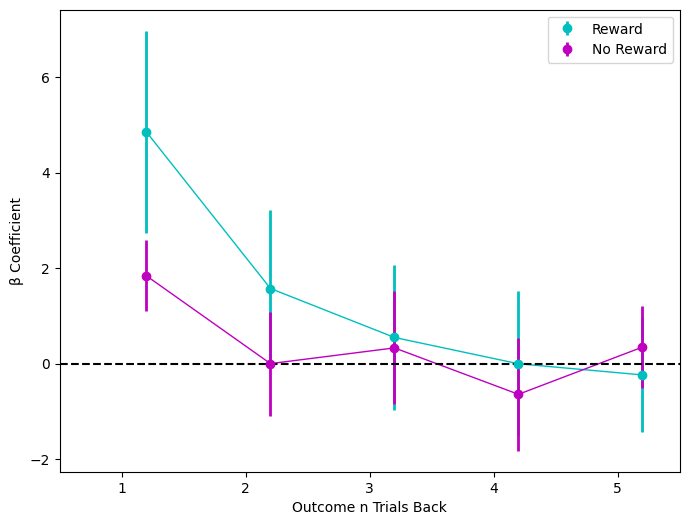

behavior_699462_2024-01-08_11-59-21
Plotting session.


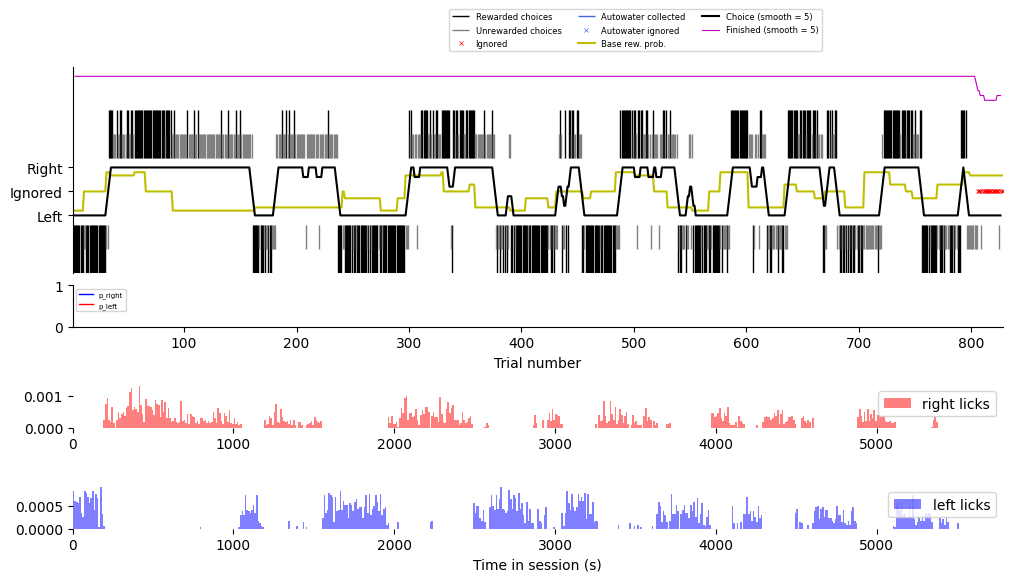

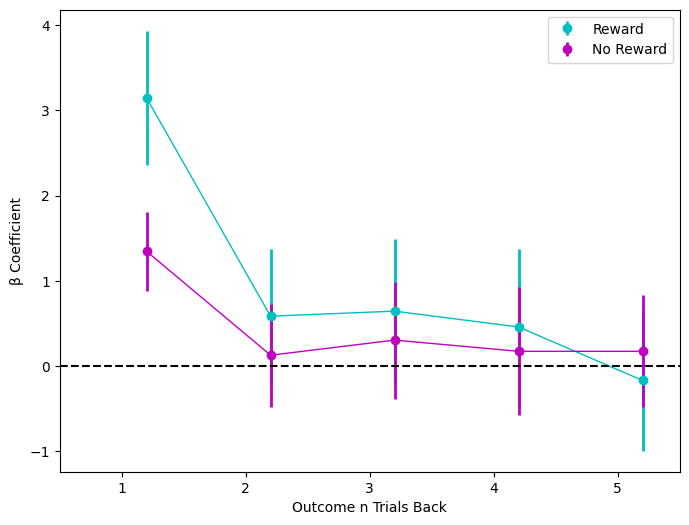

behavior_699462_2024-01-09_11-34-51
Plotting session.


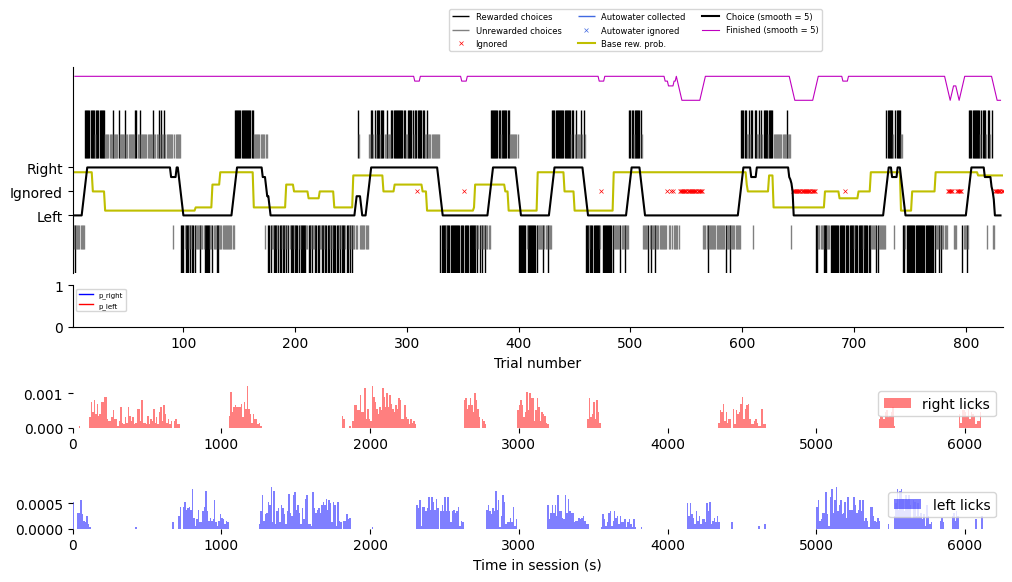

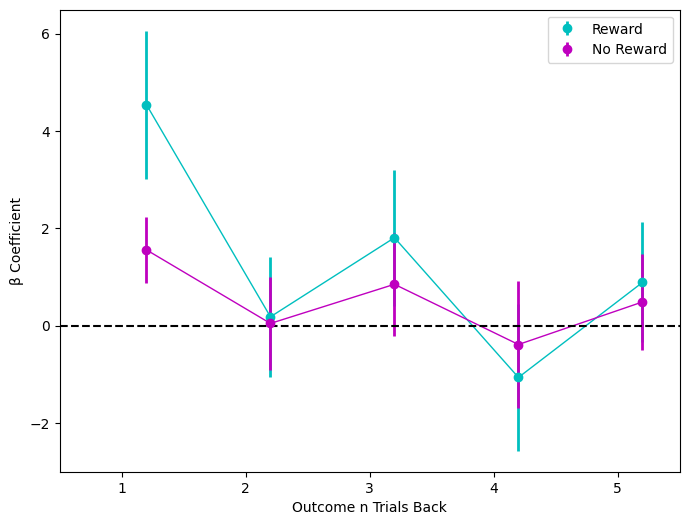

behavior_699462_2024-01-11_10-59-40
Plotting session.


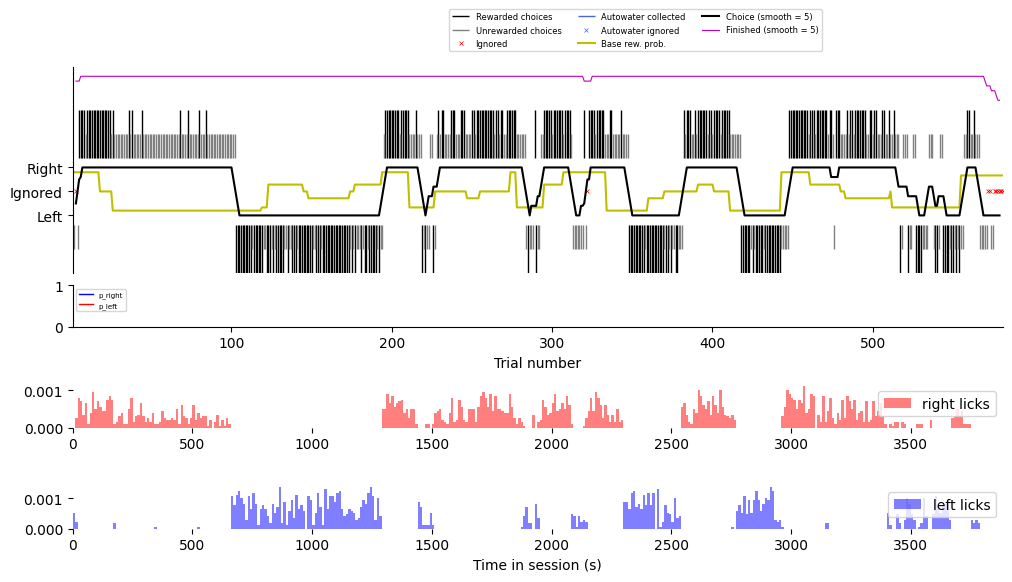

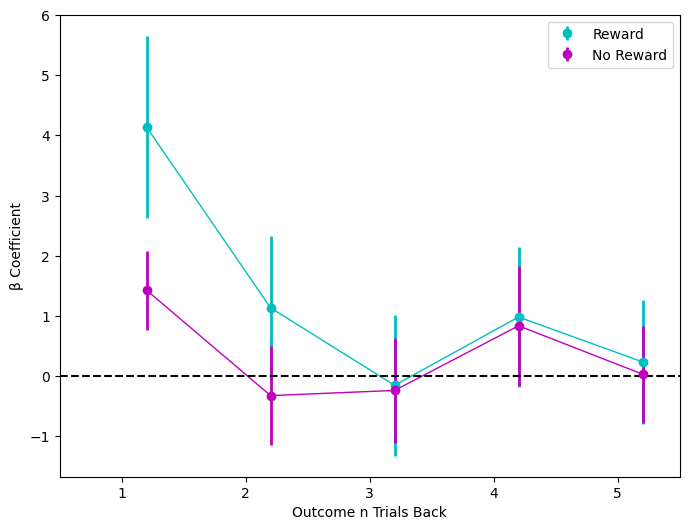

behavior_699462_2024-01-12_11-40-23
Plotting session.


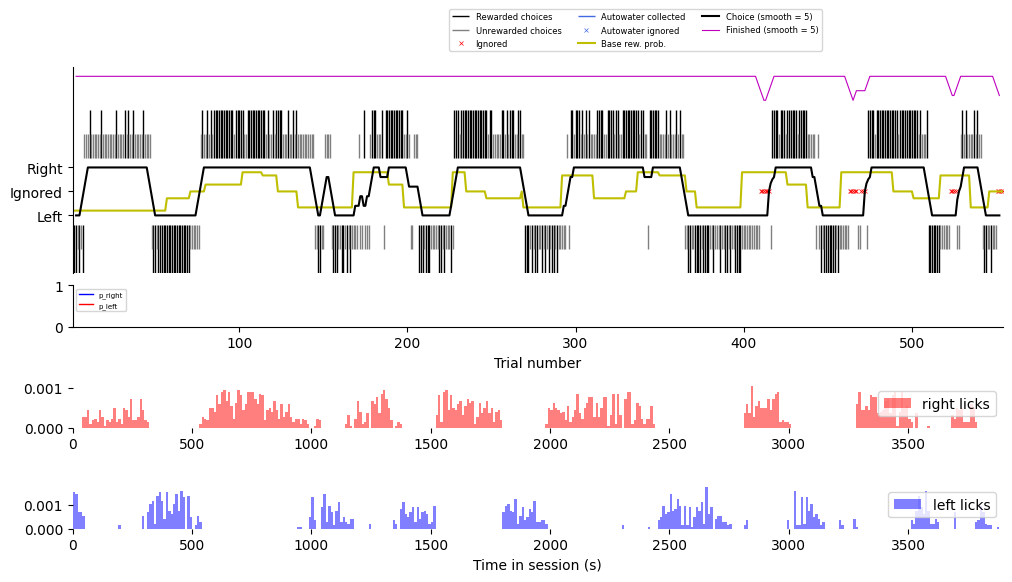

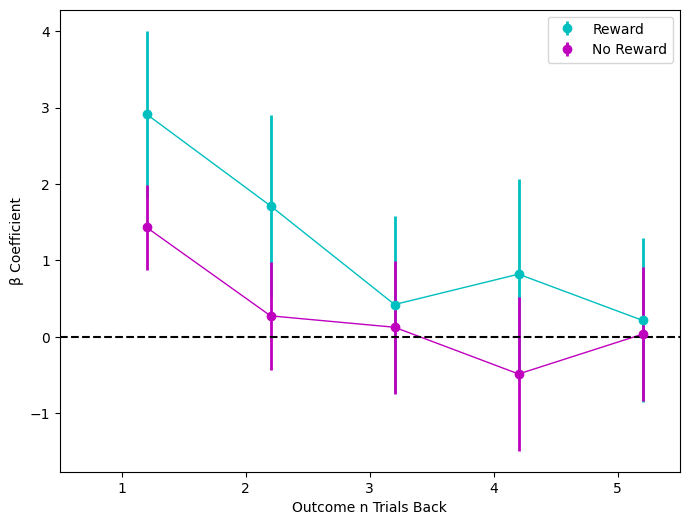

behavior_699462_2024-01-13_15-11-33
Plotting session.


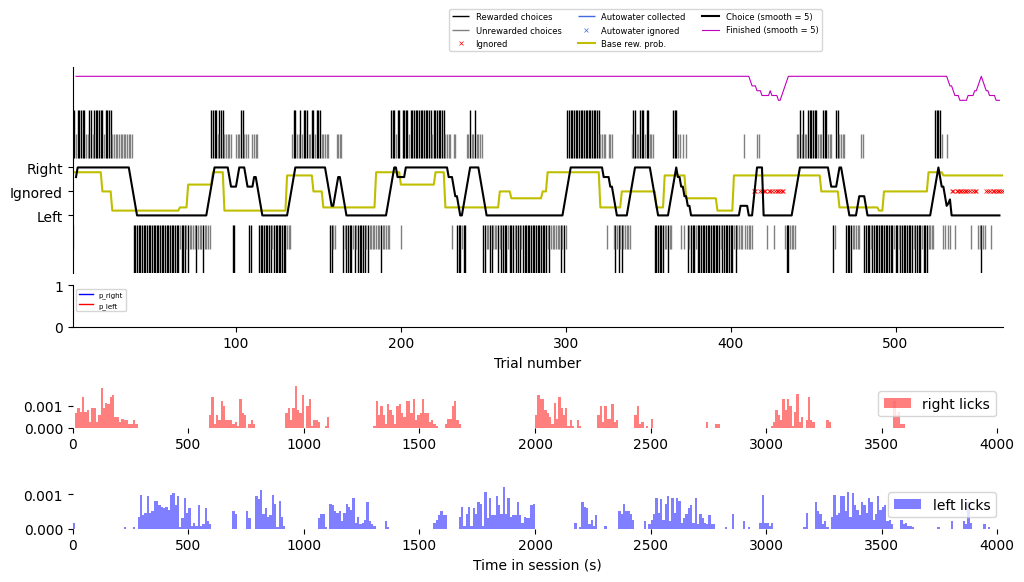

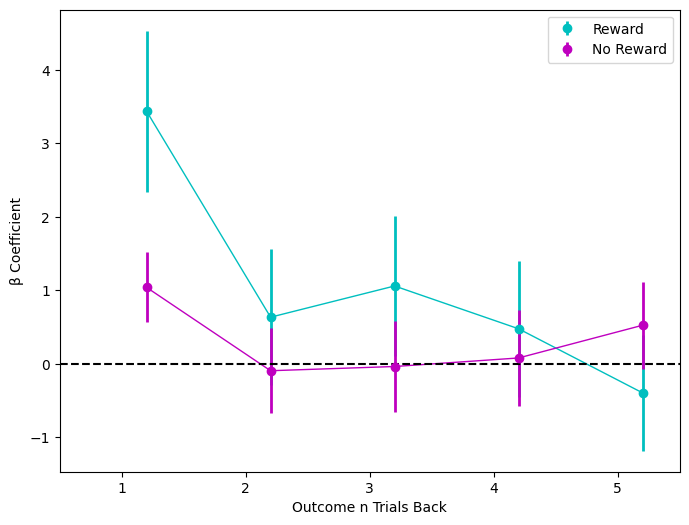

behavior_699462_2024-01-14_15-41-48
Plotting session.


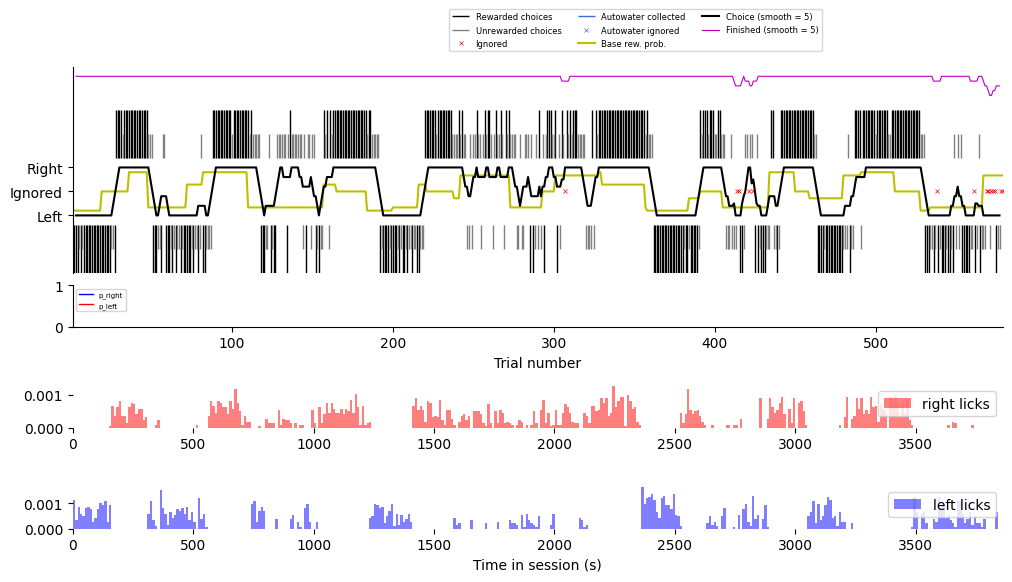

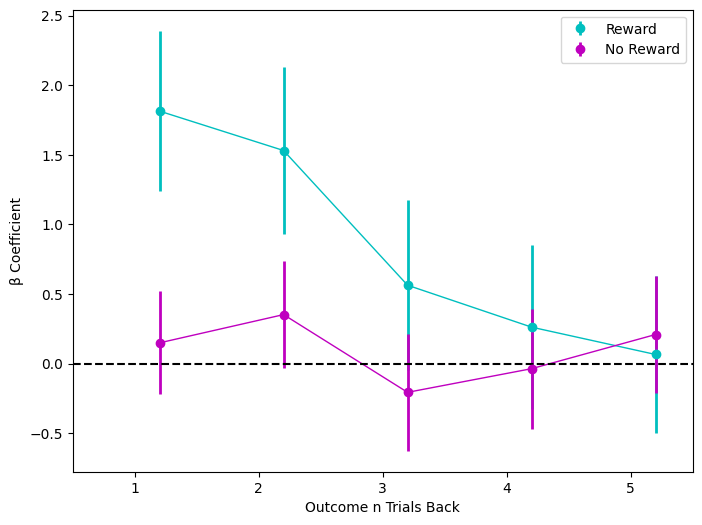

behavior_699462_2024-01-16_12-10-12
Plotting session.


/root/capsule/aind-beh-ephys-analysis/code/beh_ephys_analysis/utils/beh_functions.py:1395: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, _ = plt.subplots(figsize=(12, 6))


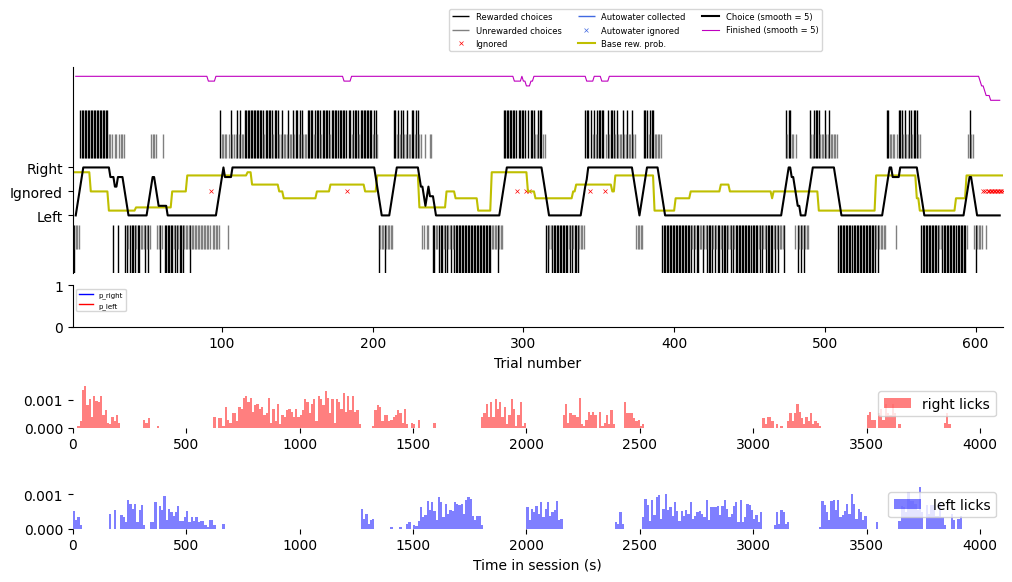

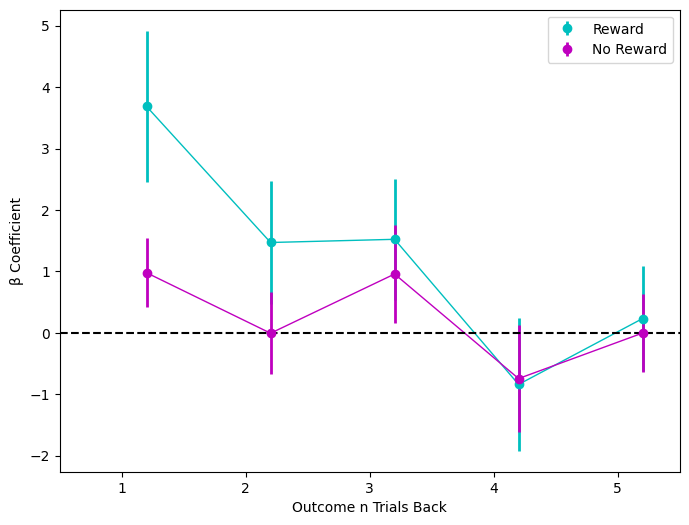

behavior_699462_2024-01-17_10-36-54
Plotting session.


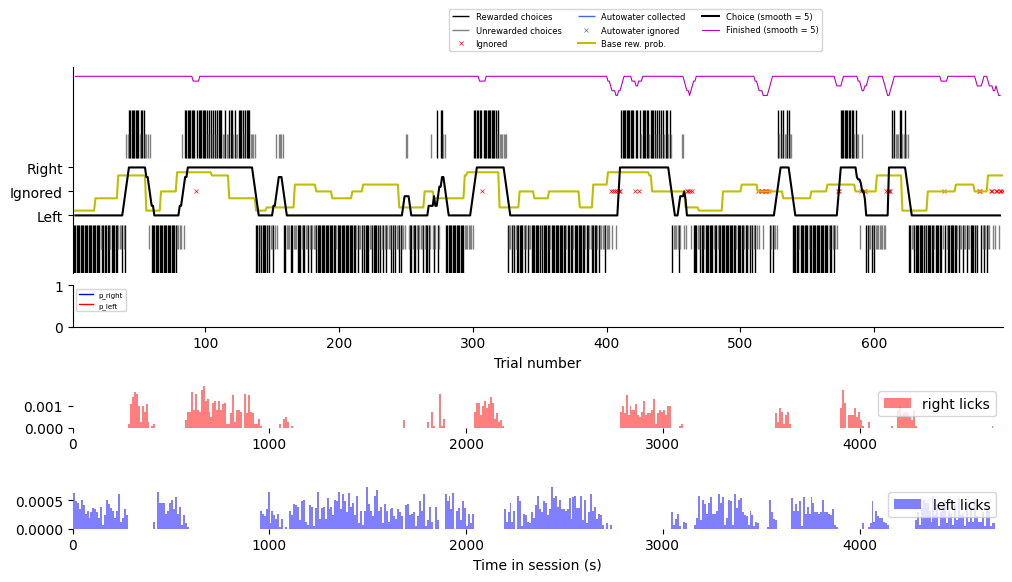

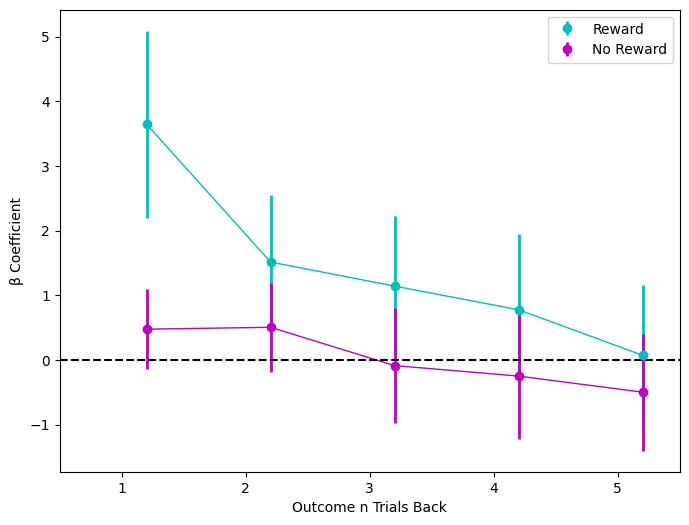

Dictionary has been saved to /root/capsule/scratch/699462/699462_session_data.csv


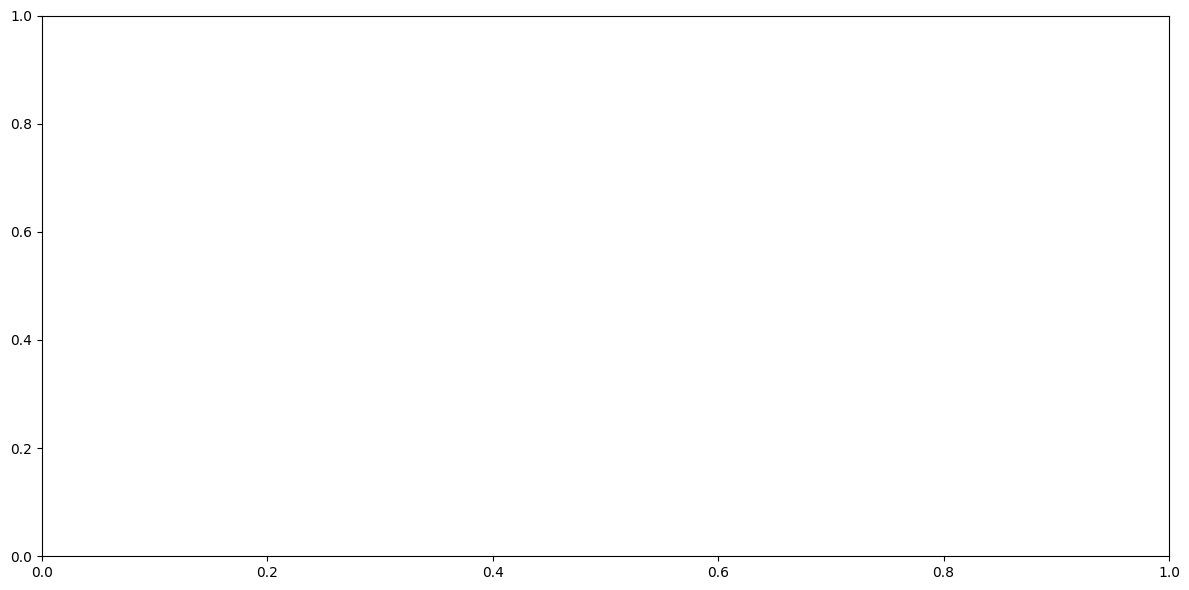

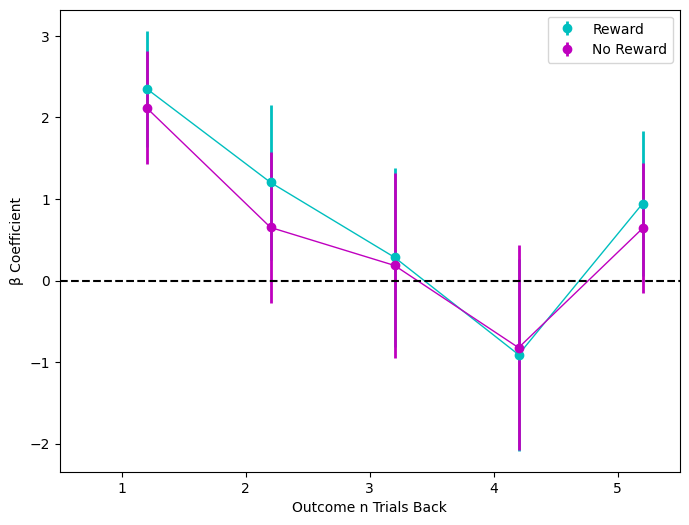

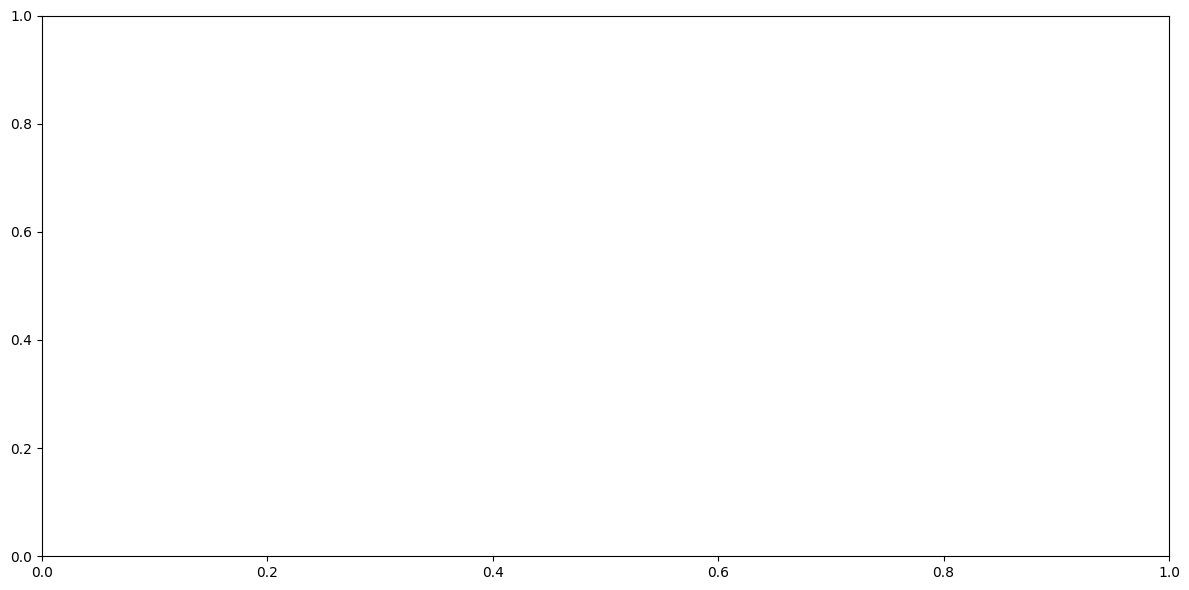

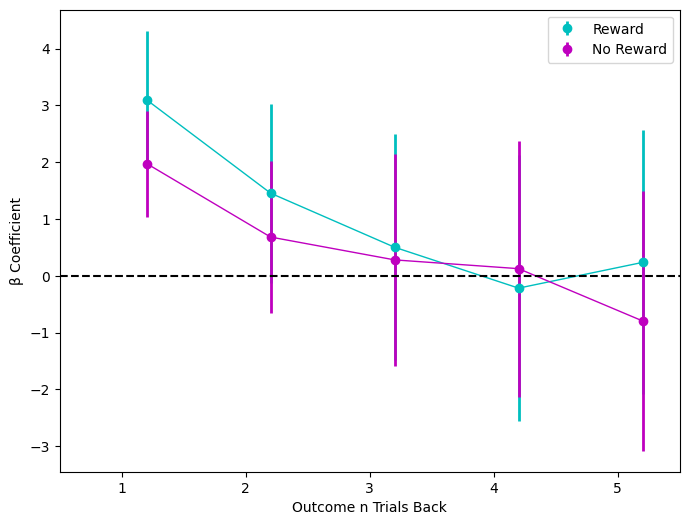

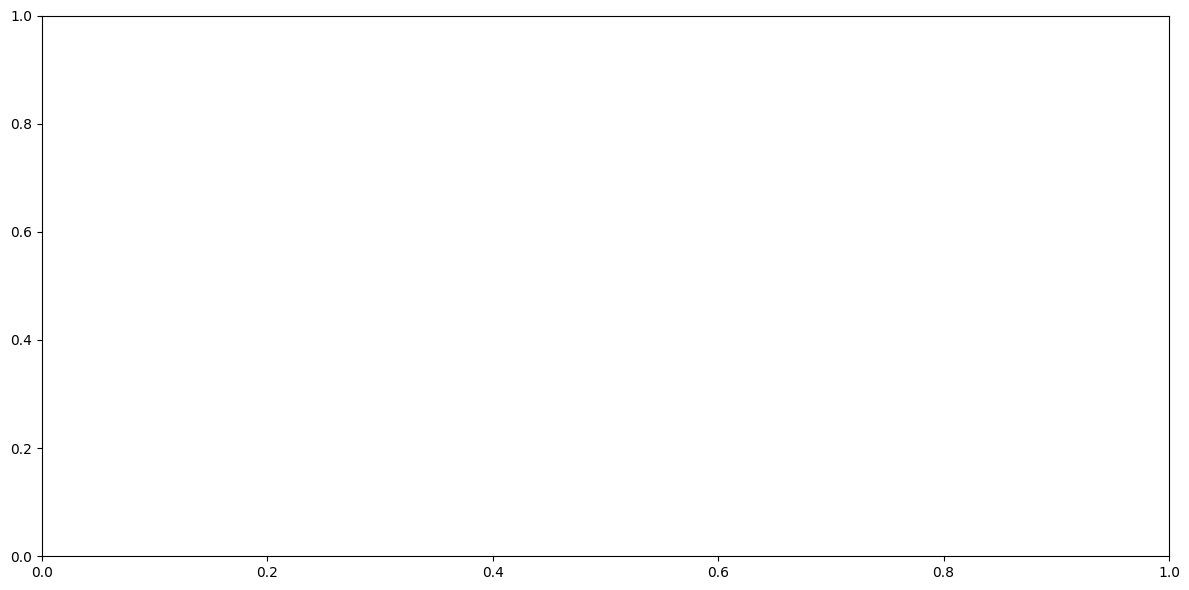

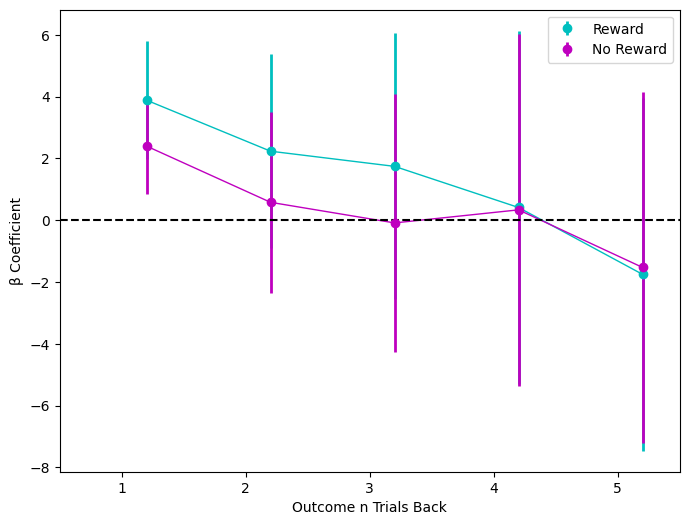

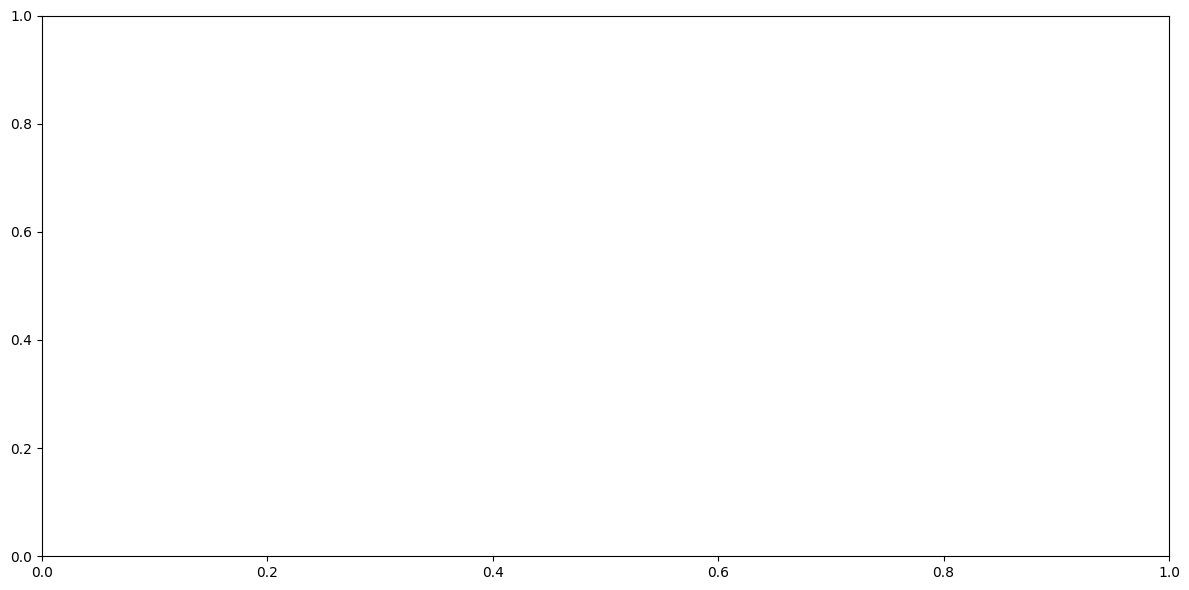

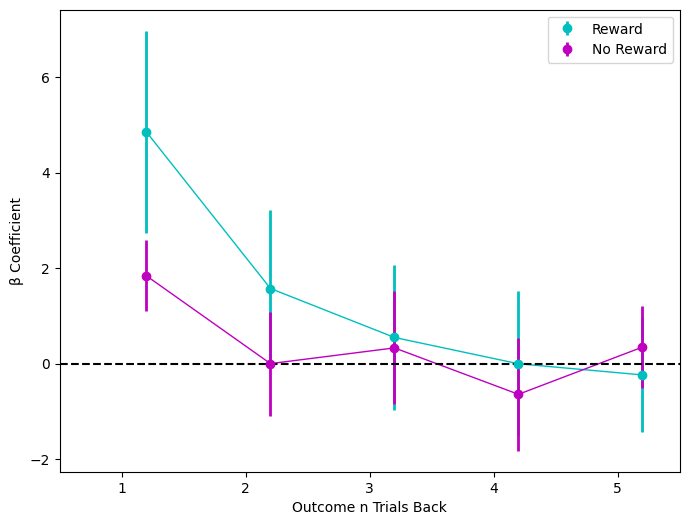

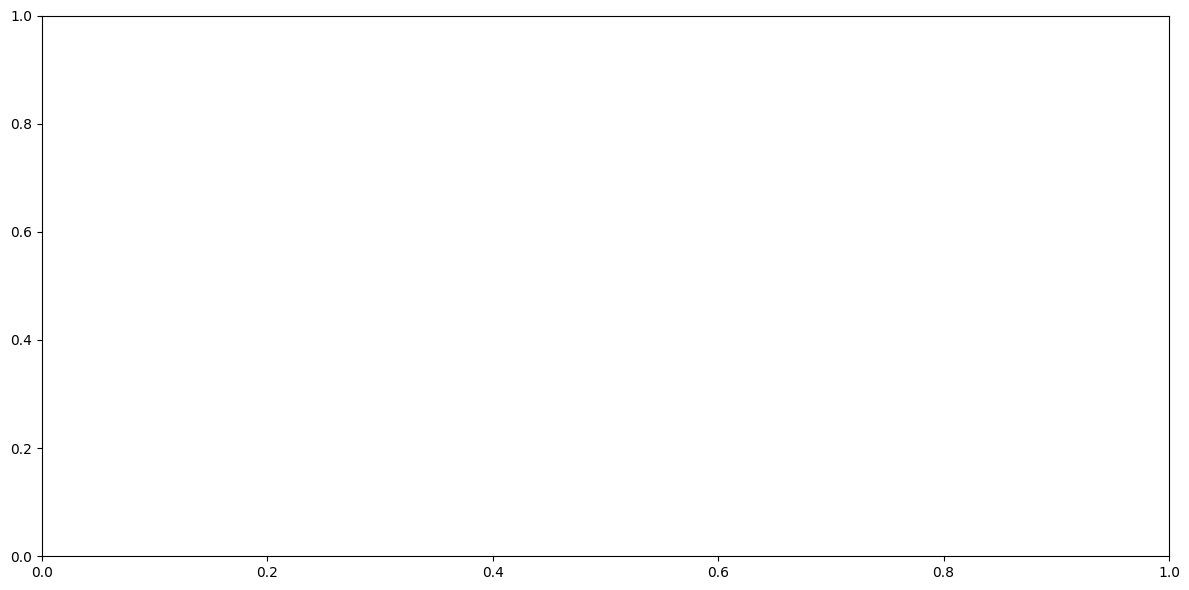

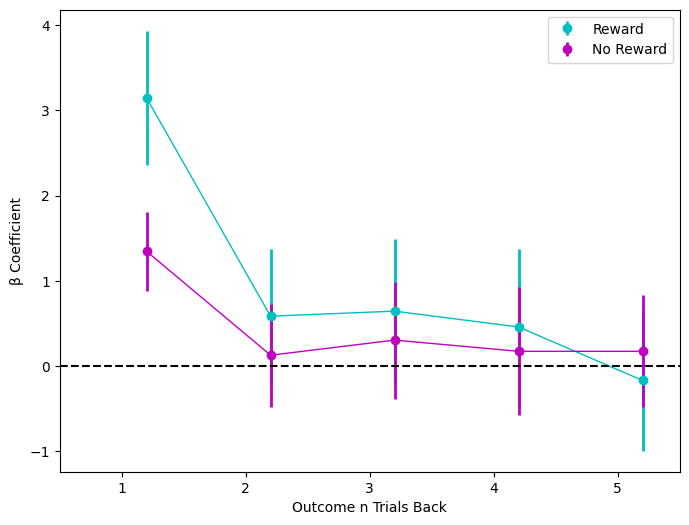

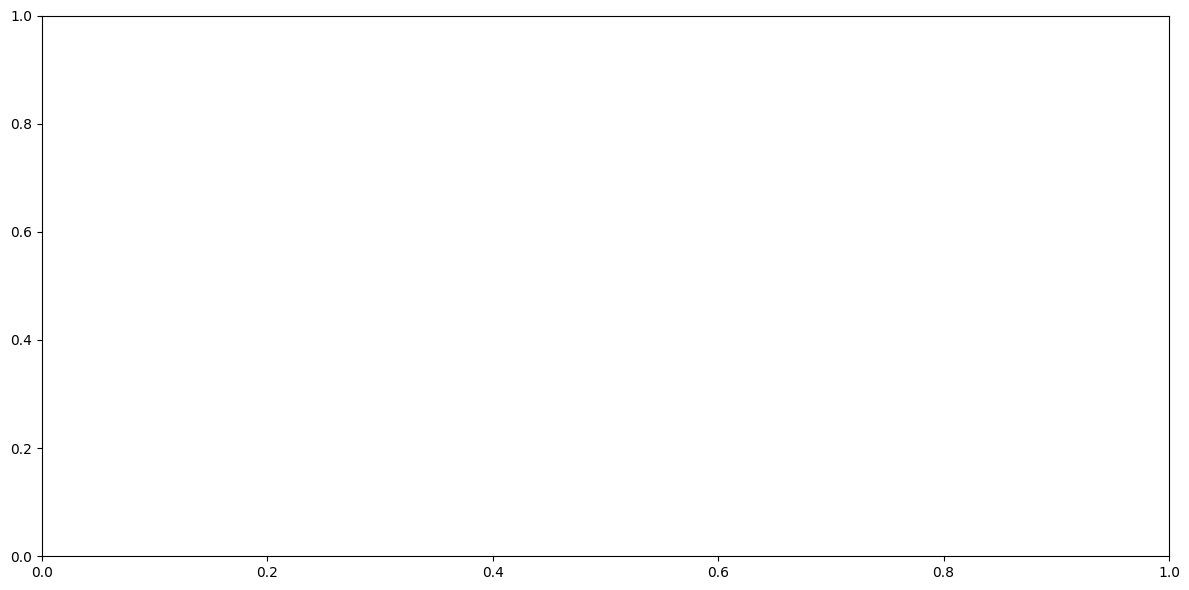

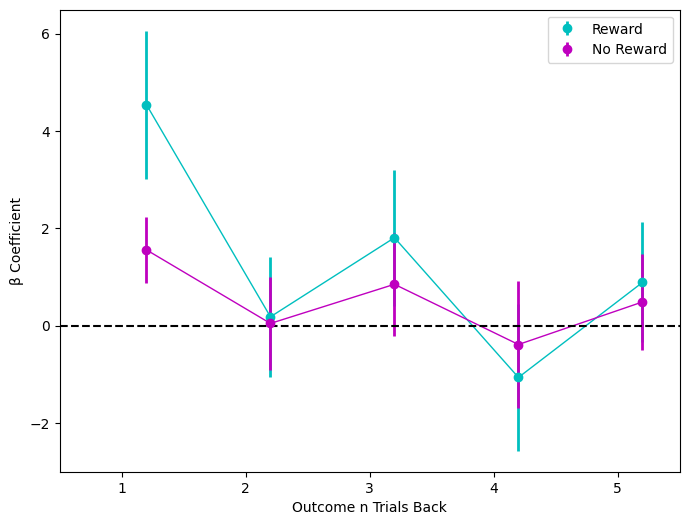

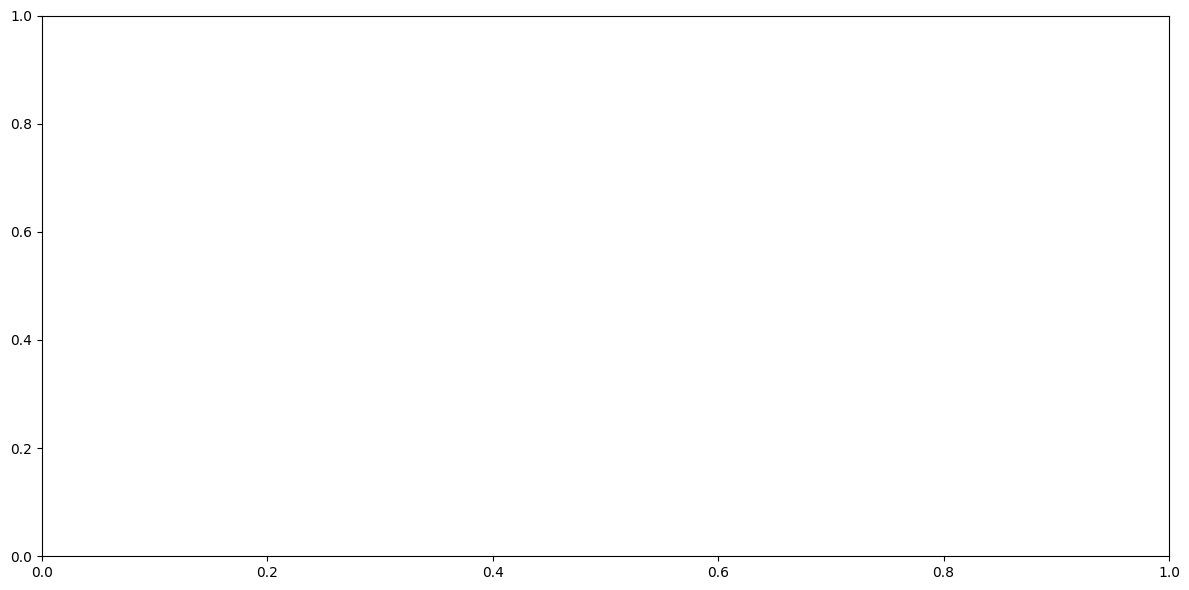

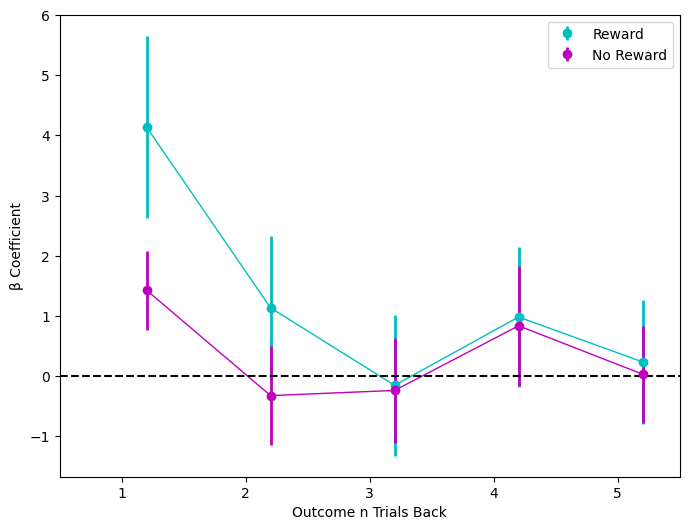

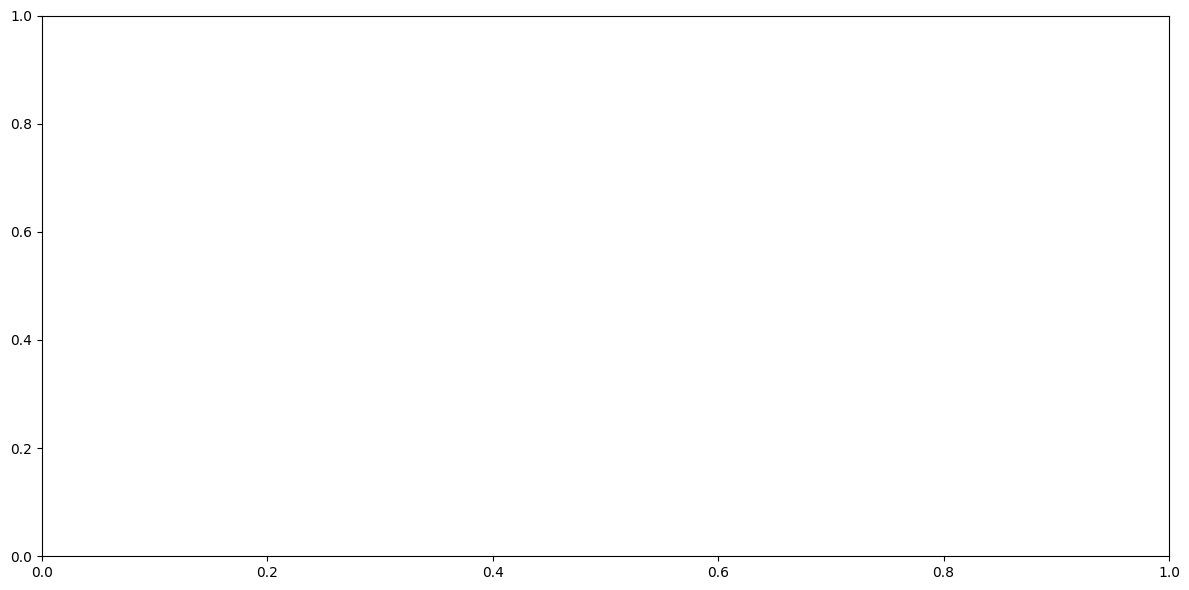

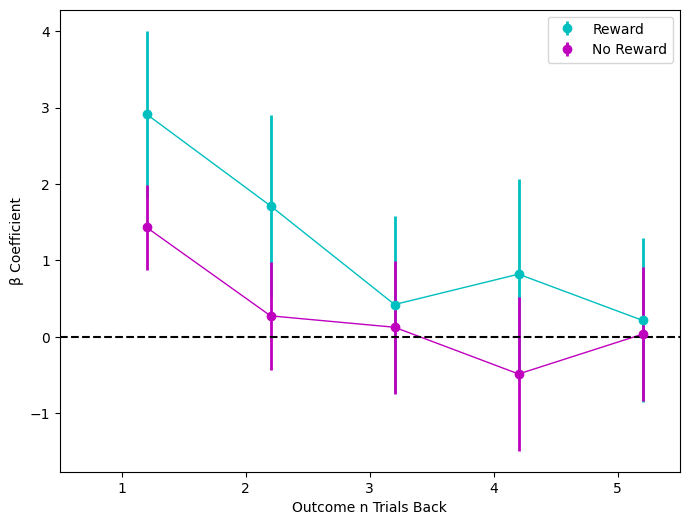

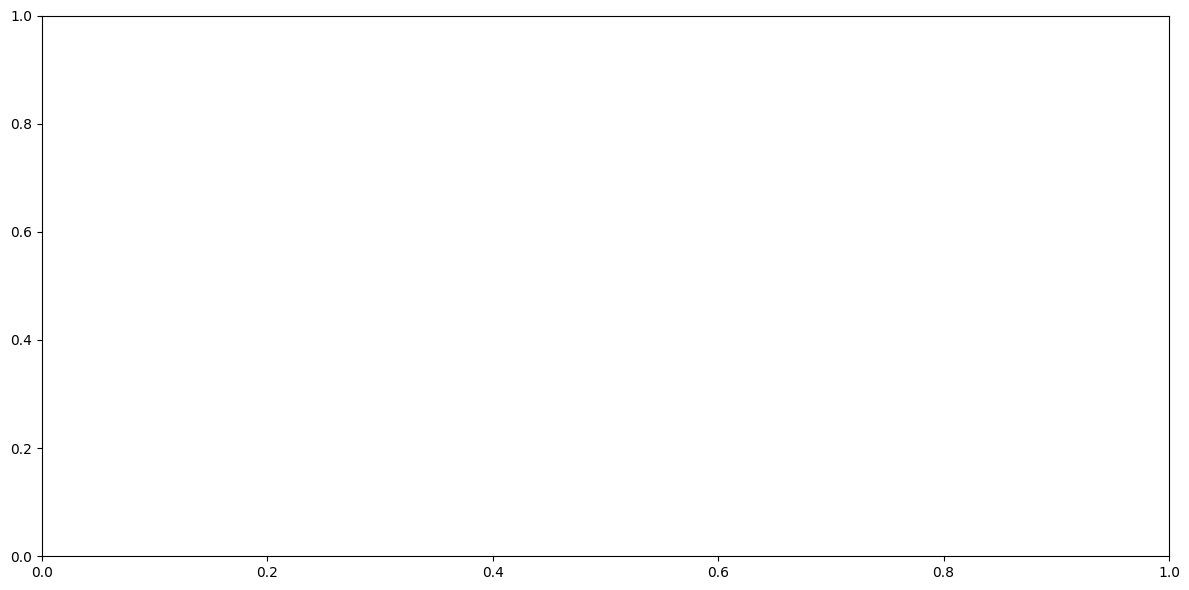

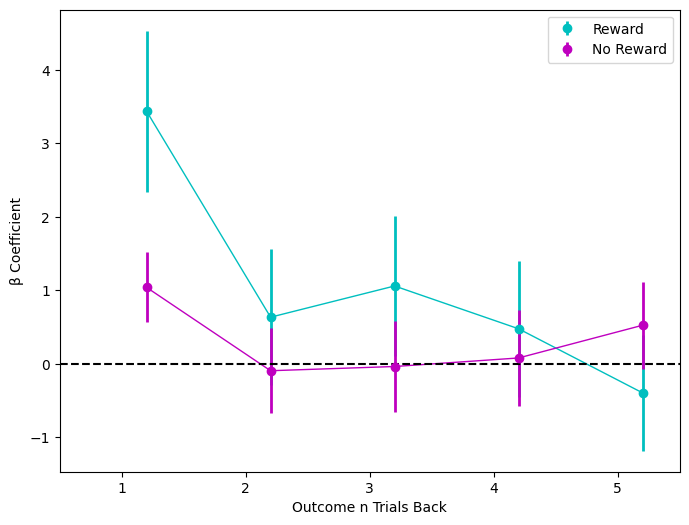

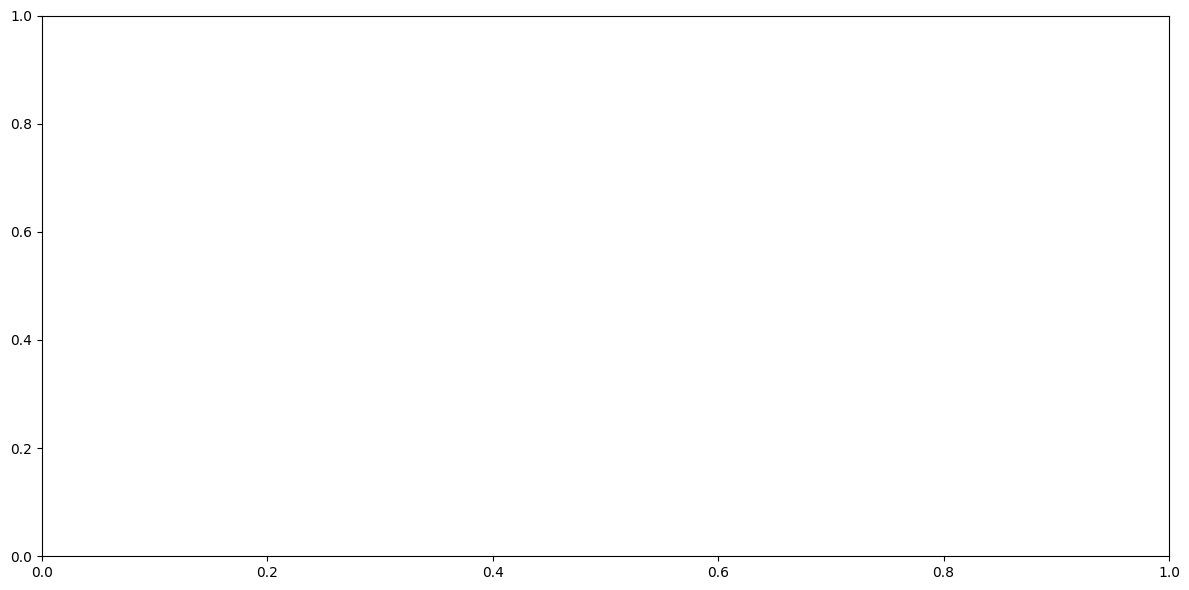

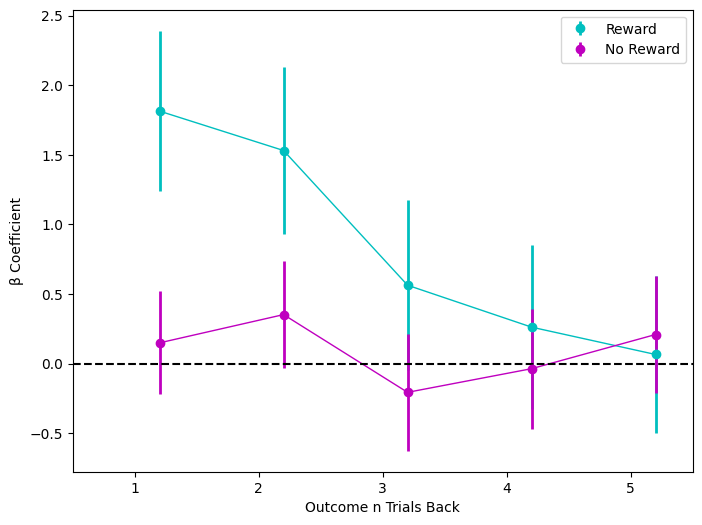

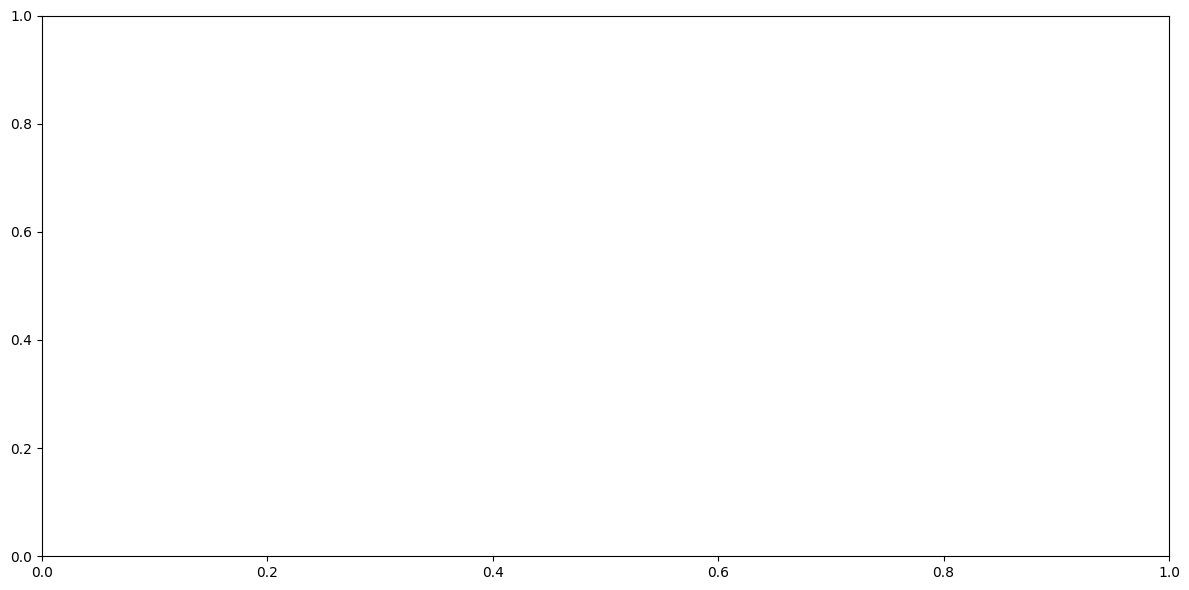

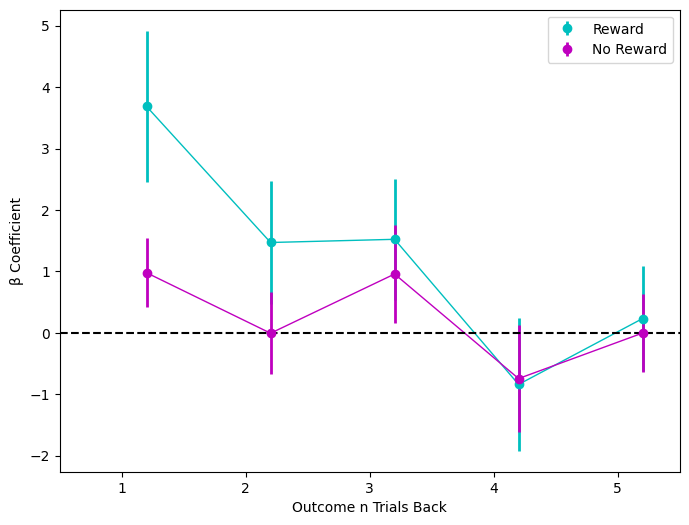

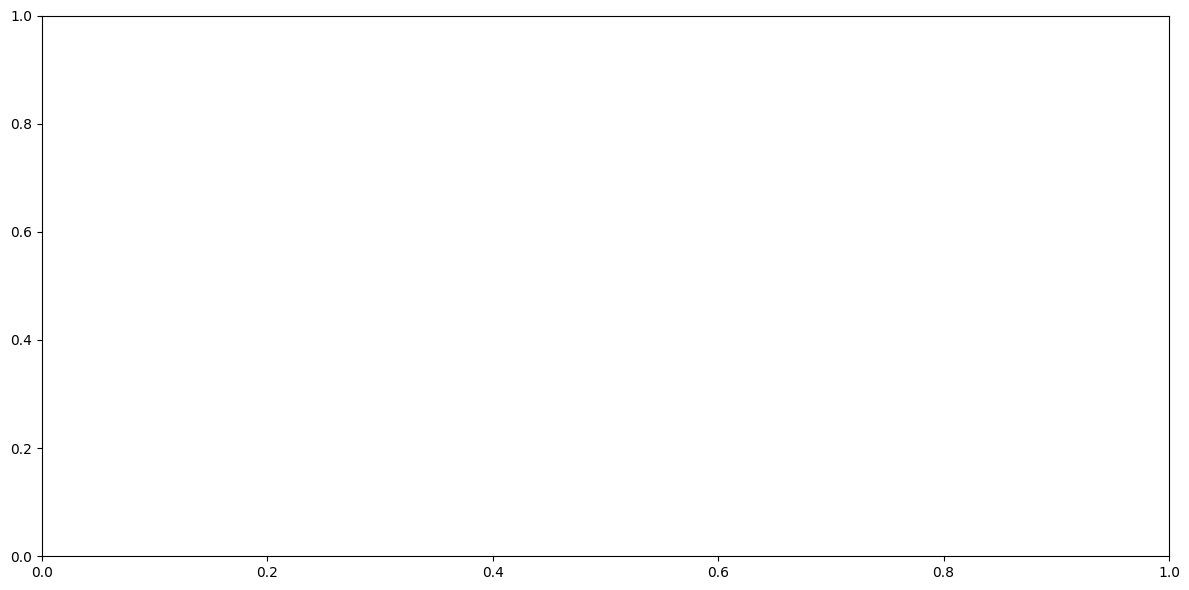

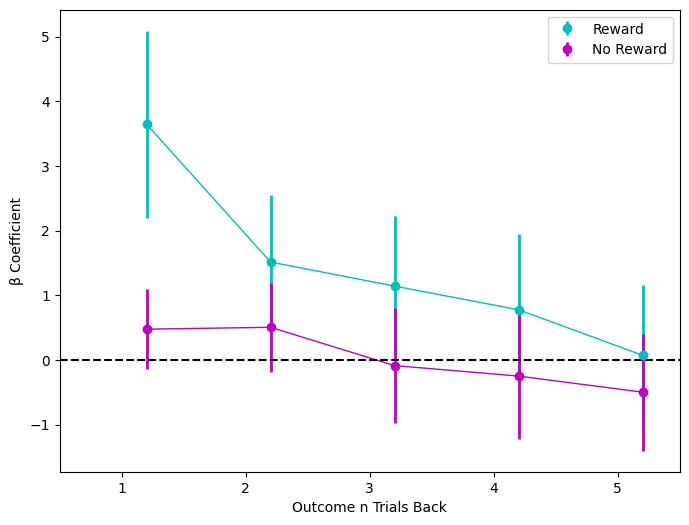

In [57]:
plt.close('all')
animal_dir = f'/root/capsule/scratch/{ani_id}'
os.makedirs(animal_dir, exist_ok=True)
ani_session_data = {'session_id': [], 'session_cut': [], 'box': []}
ani_session_file = f'/root/capsule/scratch/{ani_id}/{ani_id}_session_data.csv'
for session in session_list:
    print(session)
    session_dir = session_dirs(session)
    aniID, datetime, string = parseSessionID(session)
    nwb_file = os.path.join(session_dir['beh_fig_dir'], session + '.nwb')
    if not os.path.exists(nwb_file):
        if aniID.startswith('ZS'):
            print('Hopkins session, transferring from existing nwb.')
            transfer_nwb(session)
        else:
            session_json_dir = os.path.join(session_dir['raw_dir'], 'behavior')
            session_json_files = []
            for dir, _, files in os.walk(session_json_dir):
                for file in files:
                    if file.endswith('.json') and aniID in file and 'model' not in file:
                        session_json_files.extend([os.path.join(dir, file)])
            print(f'{len(session_json_files)} session json files found.')
            if len(session_json_files) == 1:
                session_json_file = session_json_files[0]
                if os.path.exists(os.path.join(session_dir['beh_fig_dir'], session + '.nwb')):
                    print('NWB file already exists.')
                else:
                    print('Processing NWB:')
                    success, nwb_file = bonsai_to_nwb(session_json_file, os.path.join(session_dir['beh_fig_dir'], session + '.nwb'))


    print('Plotting session.')
    nwb = load_nwb_from_filename(nwb_file)
    trial_df = nwb.trials.to_dataframe()
    ani_session_data['session_id'].append(session)
    ani_session_data['box'].append(nwb.scratch['metadata'][0].box.values[0])
    ani_session_data['session_cut'].append([0, len(trial_df)])
    fig = plot_session_in_time_all(nwb, in_time=False)
    display(fig)
    fig.savefig(os.path.join(session_dir['beh_fig_dir'], session + '_session.png'))
    fig, session_id, _ = plot_session_glm(session, tMax=5)
    fig.savefig(os.path.join(session_dir['beh_fig_dir'], session + '_glm.png'))
    display(fig)
ani_session_dataframe = pd.DataFrame(ani_session_data)
if save_csv:
    ani_session_dataframe.to_csv(ani_session_file, index=False)

    print(f"Dictionary has been saved to {ani_session_file}")   